In [1]:
import sys
import os
import tqdm
import matplotlib.pyplot as plt

build_dir = os.path.abspath('./build')
print(f"Build dir: {build_dir}")
print(f"Contents: {os.listdir(build_dir)}")  # ← CRITICAL DEBUG

sys.path.insert(0, build_dir)
if os.path.exists(build_dir):
    if os.name == 'nt':
        os.add_dll_directory(build_dir)

try:
    import tsn
    print("✅ SUCCESS!")
    print(dir(tsn))
except ImportError as e:
    print(f"❌ Import failed: {e}")
    print("Trying direct import...")
    # List all .pyd files and try importing
    for f in os.listdir(build_dir):
        if f.endswith('.pyd'):
            modname = f[:-20]  # Remove .cp312-win_amd64.pyd
            print(f"Trying {modname}...")

Build dir: c:\Users\ayush\OneDrive\Desktop\pybind_test\build
Contents: ['.cmake', 'ALL_BUILD.dir', 'ALL_BUILD.vcxproj', 'ALL_BUILD.vcxproj.filters', 'CMakeCache.txt', 'CMakeFiles', 'cmake_install.cmake', 'compile_commands.json', 'Debug', 'libatomic-1.dll', 'libgcc_s_seh-1.dll', 'libstdc++-6.dll', 'libwinpthread-1.dll', 'Makefile', 'pybind_test.sln', 'tsn.cp312-win_amd64.pyd', 'tsn.dir', 'tsn.vcxproj', 'tsn.vcxproj.filters', 'x64', 'ZERO_CHECK.dir', 'ZERO_CHECK.vcxproj', 'ZERO_CHECK.vcxproj.filters']
✅ SUCCESS!
['AlgoResults', 'DepartureTimes', 'ItemsView', 'KeysView', 'Message', 'Routes', 'ValuesView', 'VectorInt', 'VectorMessage', 'VectorVectorInt', 'Vectordouble', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'algo', 'makeInputs']


In [2]:
import time
def check_overlap(messages,results):
    hyper_period = results.hyperperiod
    time = [dict() for i in range(hyper_period)]

    for msg in range(len(results.amount_sent)):
        for rep in range(len(results.amount_sent[msg])):
            for i in range(len(results.R[(msg,rep)])):

                route = results.R[(msg,rep)][i]
                start_time = results.departure_times[(msg,rep)][i]
                for idx in range(len(route) - 1):
                    u = min(route[idx],route[idx+1])
                    v = max(route[idx],route[idx+1])

                    for busy in range(messages[msg].size):
                        if(start_time + busy < hyper_period):
                            time[start_time + busy][(u,v)] = time[start_time + busy].get((u,v),0) + 1
                    start_time+=1

    flag = 1
    for d in time:
        for x,y in d.items():
            if(y > 1): 
                flag = 0

    return flag

def successfulPercetage(messages,results):
    fail = 0
    total = 0
    for msg in range(len(results.reps)):
        total += 1
        for rep in range(results.reps[msg]):
            if results.amount_sent[msg][rep] != messages[msg].tl:
                fail += 1
                break
    return 1 - fail/total

In [3]:
def get_edgesweights(results):
    edgeweights = {}
    for msg in range(len(results.amount_sent)):
        for rep in range(len(results.amount_sent[msg])):
            for i in range(len(results.R[(msg,rep)])):

                route = results.R[(msg,rep)][i]
                for idx in range(len(route) - 1):
                    u = min(route[idx],route[idx+1])
                    v = max(route[idx],route[idx+1])
                    edgeweights[(u,v)] = edgeweights.get((u,v),0) + 1
    
    return edgeweights

def get_message_mats(num_ecu,M,results):
    ret1 = [[0 for i in range(num_ecu)] for j in range(num_ecu)]
    ret2 = [[0 for i in range(num_ecu)] for j in range(num_ecu)]
    
    for m in M: ret1[m.src][m.sink] += 1

    for msg in range(len(results.reps)):
        for rep in range(results.reps[msg]):
            if results.amount_sent[msg][rep] != M[msg].tl:
                ret2[M[msg].src][M[msg].sink] += 1
                break
            
    return ret1, ret2
    

In [4]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from itertools import combinations

def draw_annotated_matrix(ax, matrix, title, cmap='Blues'):
    """Helper to draw a 2D array as a heatmap with text annotations."""
    cax = ax.matshow(matrix, cmap=cmap)
    
    # Add text annotations for each cell
    max_val = np.max(matrix)
    for i in range(len(matrix)):
        for j in range(len(matrix[0])):
            val = matrix[i][j]
            # Use white text on dark backgrounds, black on light
            text_color = "white" if val > (max_val / 2) else "black"
            # Format to avoid excessively long floats if they occur
            val_str = f"{val:.1f}" if isinstance(val, float) else str(val)
            ax.text(j, i, val_str, ha="center", va="center", color=text_color, fontsize=9)
            
    # Moved pad slightly higher so the title doesn't overlap with the new top labels
    ax.set_title(title, pad=20, fontweight='bold')
    ax.set_xticks(range(len(matrix[0])))
    ax.set_yticks(range(len(matrix)))
    
    # Set ticks and labels to appear at the top instead of the bottom
    ax.tick_params(axis='x', bottom=False, top=True, labelbottom=False, labeltop=True)

def visualize_topology_and_matrices_polyinpoly(num_type1, num_type2, edges, matrix1, matrix2, r_outer=2.0, r_inner=1.0):
    # Setup grid layout: Graph on the left (spans 2 rows), matrices on the right (stacked)
    fig = plt.figure(figsize=(15, 9))
    gs = fig.add_gridspec(2, 2, width_ratios=[2.5, 1])
    
    ax_graph = fig.add_subplot(gs[:, 0])
    ax_mat1 = fig.add_subplot(gs[0, 1])
    ax_mat2 = fig.add_subplot(gs[1, 1])

    # --- 1. Draw Graph ---
    G = nx.Graph()
    pos = {}
    total_nodes = num_type1 + num_type2
    
    # Outer polygon (Type 1 nodes)
    for i in range(num_type1):
        angle = 2 * np.pi * i / num_type1
        pos[i] = (r_outer * np.cos(angle), r_outer * np.sin(angle))
        
    # Inner polygon (Type 2 nodes)
    for i in range(num_type2):
        node_id = num_type1 + i
        angle = 2 * np.pi * i / num_type2
        pos[node_id] = (r_inner * np.cos(angle), r_inner * np.sin(angle))
        
    G.add_nodes_from(range(total_nodes))
    
    active_edges = []
    inactive_edges = []
    weights = []
    
    # Standardize input edges (u < v)
    parsed_edges = {}
    for (u, v), w in edges.items():
        u, v = min(u, v), max(u, v)
        if w < 2147483647:  # Ignore INT32_MAX
            parsed_edges[(u, v)] = w
            
    # Classify all possible fully-connected edges
    for u, v in combinations(range(total_nodes), 2):
        if (u, v) in parsed_edges:
            active_edges.append((u, v))
            weights.append(parsed_edges[(u, v)])
            G.add_edge(u, v, weight=parsed_edges[(u, v)])
        else:
            inactive_edges.append((u, v))
            G.add_edge(u, v, weight=0)

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax_graph, nodelist=range(num_type1), 
                           node_color='lightblue', node_size=600, label='Type 1 (Outer)')
    nx.draw_networkx_nodes(G, pos, ax=ax_graph, nodelist=range(num_type1, total_nodes), 
                           node_color='lightgreen', node_size=600, label='Type 2 (Inner)')
    
    # Draw inactive edges
    if inactive_edges:
        nx.draw_networkx_edges(G, pos, ax=ax_graph, edgelist=inactive_edges, 
                               width=0.5, alpha=0.3, style='dotted', edge_color='gray')
        
    # Draw active edges
    if active_edges:
        min_w = min(weights)
        max_w = max(weights)
        for (u, v) in active_edges:
            w = parsed_edges[(u, v)]
            alpha = 1.0 if max_w == min_w else 0.2 + 0.8 * (w - min_w) / (max_w - min_w)
            nx.draw_networkx_edges(G, pos, ax=ax_graph, edgelist=[(u, v)], width=2.5, alpha=alpha, edge_color='black')
        
    nx.draw_networkx_labels(G, pos, ax=ax_graph, font_size=10, font_family="sans-serif", font_weight='bold')
    ax_graph.set_title("Topology", fontweight='bold')
    ax_graph.legend(scatterpoints=1)
    ax_graph.axis('off')

    # --- 2. Draw Matrices ---
    draw_annotated_matrix(ax_mat1, matrix1, "Messages Total", cmap='Oranges')
    draw_annotated_matrix(ax_mat2, matrix2, "Messages Failed", cmap='Purples')

    plt.tight_layout()
    plt.show()

In [5]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from itertools import combinations

def draw_annotated_matrix(ax, matrix, title, cmap='Blues'):
    """Helper to draw a 2D array as a heatmap with text annotations."""
    cax = ax.matshow(matrix, cmap=cmap)
    
    # Add text annotations for each cell
    max_val = np.max(matrix)
    for i in range(len(matrix)):
        for j in range(len(matrix[0])):
            val = matrix[i][j]
            # Use white text on dark backgrounds, black on light
            text_color = "white" if val > (max_val / 2) else "black"
            # Format to avoid excessively long floats if they occur
            val_str = f"{val:.1f}" if isinstance(val, float) else str(val)
            ax.text(j, i, val_str, ha="center", va="center", color=text_color, fontsize=9)
            
    # Moved pad slightly higher so the title doesn't overlap with the new top labels
    ax.set_title(title, pad=20, fontweight='bold')
    ax.set_xticks(range(len(matrix[0])))
    ax.set_yticks(range(len(matrix)))
    
    # Set ticks and labels to appear at the top instead of the bottom
    ax.tick_params(axis='x', bottom=False, top=True, labelbottom=False, labeltop=True)

def visualize_topology_and_matrices_polybypoly(num_type1, num_type2, edges, matrix1, matrix2, radius=2.0, x_offset=3.0):
    # Setup grid layout: Graph on the left (spans 2 rows), matrices on the right (stacked)
    fig = plt.figure(figsize=(15, 9))
    gs = fig.add_gridspec(2, 2, width_ratios=[2.5, 1])
    
    ax_graph = fig.add_subplot(gs[:, 0])
    ax_mat1 = fig.add_subplot(gs[0, 1])
    ax_mat2 = fig.add_subplot(gs[1, 1])

    # --- 1. Draw Graph ---
    G = nx.Graph()
    pos = {}
    total_nodes = num_type1 + num_type2
    
    # Left polygon (Type 1 nodes)
    for i in range(num_type1):
        angle = 2 * np.pi * i / num_type1
        pos[i] = (-x_offset + radius * np.cos(angle), radius * np.sin(angle))
        
    # Right polygon (Type 2 nodes)
    for i in range(num_type2):
        node_id = num_type1 + i
        angle = 2 * np.pi * i / num_type2
        pos[node_id] = (x_offset + radius * np.cos(angle), radius * np.sin(angle))
        
    G.add_nodes_from(range(total_nodes))
    
    active_edges = []
    inactive_edges = []
    weights = []
    
    # Standardize input edges (u < v)
    parsed_edges = {}
    for (u, v), w in edges.items():
        u, v = min(u, v), max(u, v)
        if w < 2147483647:  # Ignore INT32_MAX
            parsed_edges[(u, v)] = w
            
    # Classify all possible fully-connected edges
    for u, v in combinations(range(total_nodes), 2):
        if (u, v) in parsed_edges:
            active_edges.append((u, v))
            weights.append(parsed_edges[(u, v)])
            G.add_edge(u, v, weight=parsed_edges[(u, v)])
        # else:
        #     inactive_edges.append((u, v))
        #     G.add_edge(u, v, weight=0)
            
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax_graph, nodelist=range(num_type1), 
                           node_color='lightblue', node_size=600, label='Type 1 (Left)')
    nx.draw_networkx_nodes(G, pos, ax=ax_graph, nodelist=range(num_type1, total_nodes), 
                           node_color='lightgreen', node_size=600, label='Type 2 (Right)')
    
    # Draw inactive edges
    if inactive_edges:
        nx.draw_networkx_edges(G, pos, ax=ax_graph, edgelist=inactive_edges, 
                               width=0.5, alpha=0.3, style='dotted', edge_color='gray')
        
    # Draw active edges
    if active_edges:
        min_w = min(weights)
        max_w = max(weights)
        for (u, v) in active_edges:
            w = parsed_edges[(u, v)]
            alpha = 1.0 if max_w == min_w else min(1,0.2 + 0.8 * (w - min_w) / (max_w - min_w))
            nx.draw_networkx_edges(G, pos, ax=ax_graph, edgelist=[(u, v)], width=2.5, alpha=alpha, edge_color='black')
        
    nx.draw_networkx_labels(G, pos, ax=ax_graph, font_size=10, font_family="sans-serif", font_weight='bold')
    ax_graph.set_title("Topology", fontweight='bold')
    ax_graph.legend(scatterpoints=1)
    ax_graph.axis('off')

    # --- 2. Draw Matrices ---
    draw_annotated_matrix(ax_mat1, matrix1, "Messages Total", cmap='Oranges')
    draw_annotated_matrix(ax_mat2, matrix2, "Messages Failed", cmap='Purples')

    plt.tight_layout()
    plt.show()

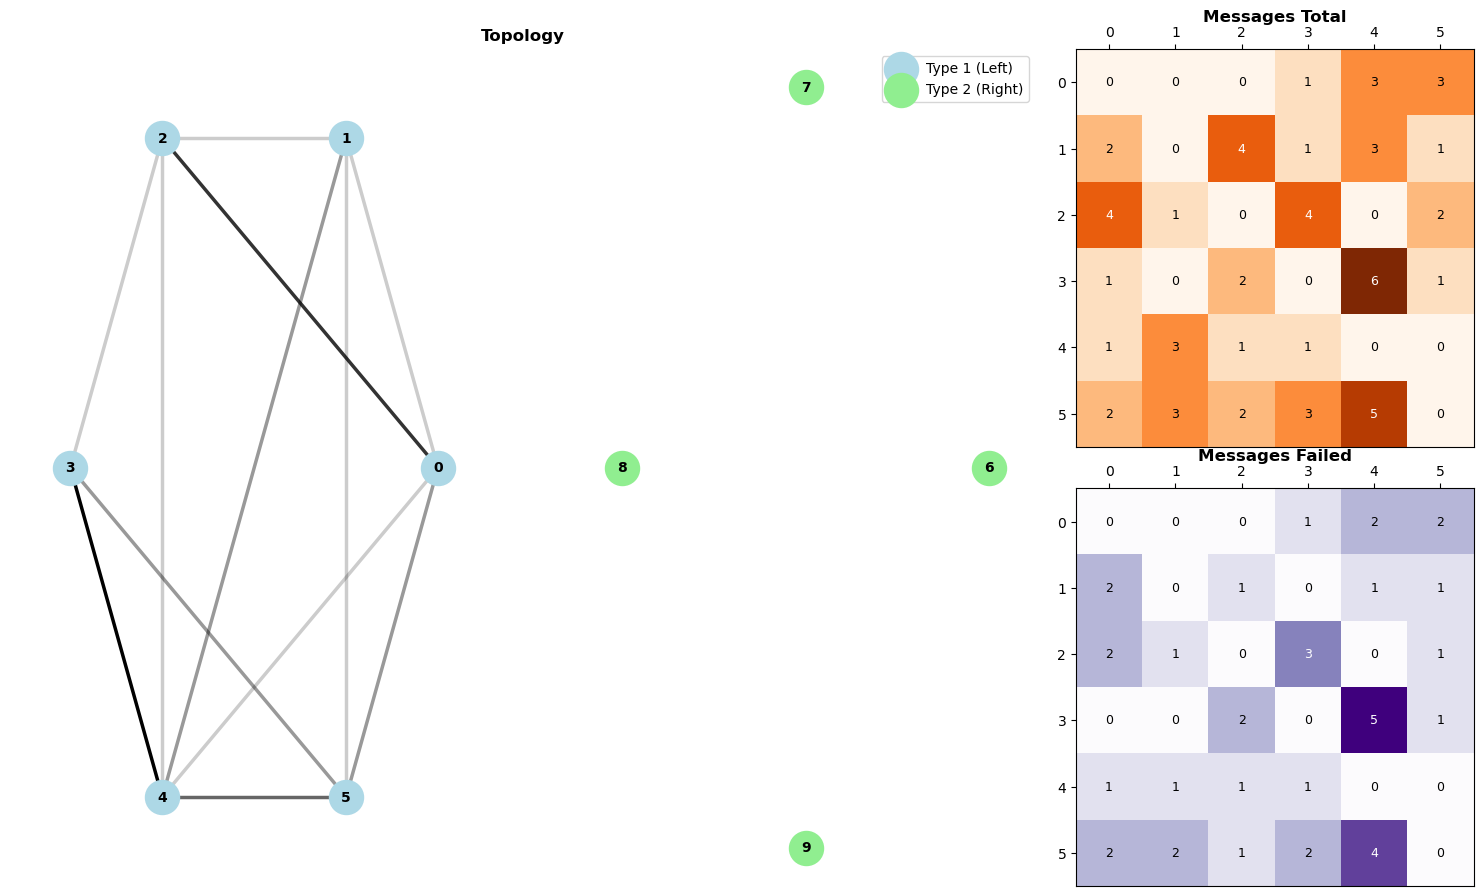

0.33333333333333337
VectorInt[2147483647, 0, 0, 6, 0, 0, 6, 6, 6, 6]
VectorInt[0, 2147483647, 0, 6, 0, 0, 6, 6, 6, 6]
VectorInt[0, 0, 2147483647, 0, 0, 6, 6, 6, 6, 6]
VectorInt[6, 6, 0, 2147483647, 0, 0, 6, 6, 6, 6]
VectorInt[0, 0, 0, 0, 2147483647, 0, 2147483647, 2147483647, 2147483647, 2147483647]
VectorInt[0, 0, 6, 0, 0, 2147483647, 6, 6, 6, 6]
VectorInt[6, 6, 6, 6, 2147483647, 6, 2147483647, 1, 1, 1]
VectorInt[6, 6, 6, 6, 2147483647, 6, 1, 2147483647, 1, 1]
VectorInt[6, 6, 6, 6, 2147483647, 6, 1, 1, 2147483647, 1]
VectorInt[6, 6, 6, 6, 2147483647, 6, 1, 1, 1, 2147483647]


In [6]:
num_ecu, num_bridges = 6, 4
bridge_limit, link_build_cost = 5, 2
base_period = 1
period_choice = tsn.VectorInt([5, 10])
period_choice_weights = tsn.Vectordouble([0.7, 0.3])
min_size, max_size = 2, 2
min_tl, max_tl = 1, 1
assignment_type = 0
yens_kmax = 20



M = tsn.makeInputs(num_ecu, num_bridges, 60, base_period, 
                               period_choice, period_choice_weights, 
                               min_size, max_size, min_tl, max_tl, 42)
output = tsn.algo(num_ecu, num_bridges, M, bridge_limit, link_build_cost, yens_kmax ,assignment_type)
mat1, mat2 = get_message_mats(num_ecu,M,output)
visualize_topology_and_matrices_polybypoly(num_ecu, num_bridges, get_edgesweights(output) , mat1, mat2)
print(successfulPercetage(M,output))
for temp in output.W:
    print(temp)

# Proof of Fragmentation

In [7]:
import matplotlib.pyplot as plt
num_ecu = 2
num_bridges = 0
bridge_limit = 1
link_build_cost = 2
assignment_type = 0
yens_kmax = 20

M = tsn.VectorMessage([tsn.Message(0,1,3,5,1),tsn.Message(0,1,3,10,1)])
output = tsn.algo(num_ecu,num_bridges,M,bridge_limit,link_build_cost,yens_kmax,assignment_type,0)

success = successfulPercetage(M,output)
print(success)

0.5


In [8]:
import matplotlib.pyplot as plt
num_ecu = 2
num_bridges = 0
bridge_limit = 1
link_build_cost = 2
assignment_type = 1
yens_kmax = 20

M = tsn.VectorMessage([tsn.Message(0,1,3,5,1),tsn.Message(0,1,3,10,1)])
output = tsn.algo(num_ecu,num_bridges,M,bridge_limit,link_build_cost,yens_kmax,assignment_type,0)

success = successfulPercetage(M,output)
print(success)

1.0


# Experimentaion

In [9]:
import matplotlib.pyplot as plt
import time

def run_experiment(assignment_type,message_counts):
    
    
    results = {
        "success_rate": [],
        "avg_cost": [],
        "avg_time": []
    }

    for num_messages in message_counts:
        print(f"Testing Assignment Type {assignment_type} | Num Messages: {num_messages}")
        total_success = 0
        total_cost = 0
        total_time = 0
        
        runs = 100
        for seed in range(runs):
            M = tsn.makeInputs(num_ecu, num_bridges, num_messages, base_period, 
                               period_choice, period_choice_weights, 
                               min_size, max_size, min_tl, max_tl, seed)

            start = time.time()
            output = tsn.algo(num_ecu, num_bridges, M, bridge_limit, link_build_cost,yens_kmax, assignment_type)
            end = time.time()

            if(check_overlap(M,output) == 0): print("Overlap Detected")

            total_success += successfulPercetage(M, output)
            total_cost += output.Cost
            total_time += (end - start)

        results["success_rate"].append(total_success / runs)
        results["avg_cost"].append(total_cost / runs)
        results["avg_time"].append(total_time / runs)
        
    return message_counts, results

# --- Setup Parameters ---
num_ecu, num_bridges = 8, 4
bridge_limit, link_build_cost = 6, 2
base_period = 1
period_choice = tsn.VectorInt([5, 10])
period_choice_weights = tsn.Vectordouble([0.7, 0.3])
min_size, max_size = 3, 3
min_tl, max_tl = 2, 2
yens_kmax = 20

# --- Run Experiments ---
x_axis, data_0 = run_experiment(0,message_counts = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120])
_, data_1 = run_experiment(1,message_counts = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120])

# --- Plotting ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. Success Rate
axs[0].plot(x_axis, data_0["success_rate"], 'o-', label='Type 0')
axs[0].plot(x_axis, data_1["success_rate"], 's--', label='Type 1')
axs[0].set_title('Success Rate vs Num Messages')
axs[0].set_xlabel('Num Messages')
axs[0].set_ylabel('Success %')
axs[0].legend()
axs[0].grid(True)

# 2. Average Topology Cost
axs[1].plot(x_axis, data_0["avg_cost"], 'o-', label='Type 0')
axs[1].plot(x_axis, data_1["avg_cost"], 's--', label='Type 1')
axs[1].set_title('Avg Topology Cost vs Num Messages')
axs[1].set_xlabel('Num Messages')
axs[1].set_ylabel('Cost')
axs[1].legend()
axs[1].grid(True)

# 3. Execution Time
axs[2].plot(x_axis, data_0["avg_time"], 'o-', label='Type 0')
axs[2].plot(x_axis, data_1["avg_time"], 's--', label='Type 1')
axs[2].set_title('Execution Time vs Num Messages')
axs[2].set_xlabel('Num Messages')
axs[2].set_ylabel('Seconds')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

Testing Assignment Type 0 | Num Messages: 10
Testing Assignment Type 0 | Num Messages: 20
Testing Assignment Type 0 | Num Messages: 30


KeyboardInterrupt: 

Testing Assignment Type 0 | Num Messages: 10
Testing Assignment Type 0 | Num Messages: 20
Testing Assignment Type 0 | Num Messages: 30
Testing Assignment Type 0 | Num Messages: 40
Testing Assignment Type 0 | Num Messages: 50
Testing Assignment Type 0 | Num Messages: 60
Testing Assignment Type 0 | Num Messages: 70
Testing Assignment Type 0 | Num Messages: 80
Testing Assignment Type 0 | Num Messages: 90
Testing Assignment Type 0 | Num Messages: 100
Testing Assignment Type 0 | Num Messages: 110
Testing Assignment Type 0 | Num Messages: 120
Testing Assignment Type 1 | Num Messages: 10
Testing Assignment Type 1 | Num Messages: 20
Testing Assignment Type 1 | Num Messages: 30
Testing Assignment Type 1 | Num Messages: 40
Testing Assignment Type 1 | Num Messages: 50
Testing Assignment Type 1 | Num Messages: 60
Testing Assignment Type 1 | Num Messages: 70
Testing Assignment Type 1 | Num Messages: 80
Testing Assignment Type 1 | Num Messages: 90
Testing Assignment Type 1 | Num Messages: 100
Testin

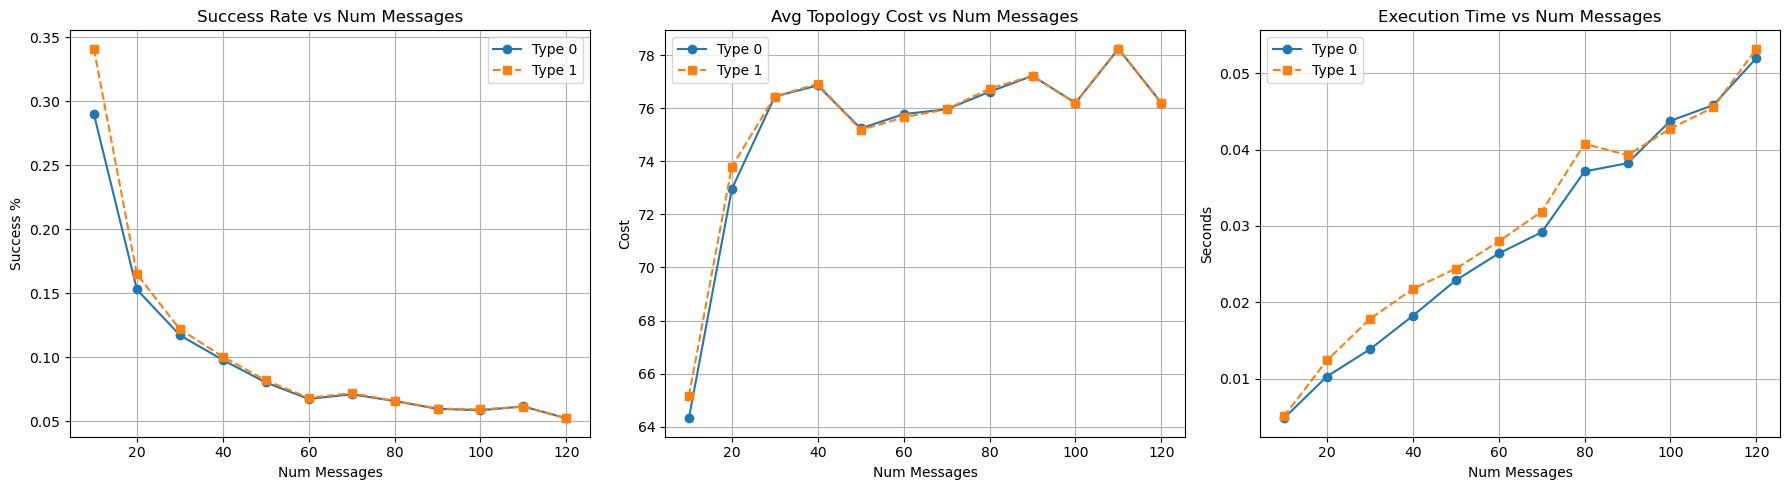

In [ ]:
# --- Setup Parameters ---
num_ecu, num_bridges = 8, 4
bridge_limit, link_build_cost = 3, 2
base_period = 1
period_choice = tsn.VectorInt([7, 14, 28])
period_choice_weights = tsn.Vectordouble([0.6, 0.3, 0.1])
min_size, max_size = 4,4
min_tl, max_tl = 2, 2
yens_kmax = 20

# --- Run Experiments ---
x_axis, data_0 = run_experiment(0,message_counts = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120])
x_axis, data_1 = run_experiment(1,message_counts = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120])

# --- Plotting ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. Success Rate
axs[0].plot(x_axis, data_0["success_rate"], 'o-', label='Type 0')
axs[0].plot(x_axis, data_1["success_rate"], 's--', label='Type 1')
axs[0].set_title('Success Rate vs Num Messages')
axs[0].set_xlabel('Num Messages')
axs[0].set_ylabel('Success %')
axs[0].legend()
axs[0].grid(True)

# 2. Average Topology Cost
axs[1].plot(x_axis, data_0["avg_cost"], 'o-', label='Type 0')
axs[1].plot(x_axis, data_1["avg_cost"], 's--', label='Type 1')
axs[1].set_title('Avg Topology Cost vs Num Messages')
axs[1].set_xlabel('Num Messages')
axs[1].set_ylabel('Cost')
axs[1].legend()
axs[1].grid(True)

# 3. Execution Time
axs[2].plot(x_axis, data_0["avg_time"], 'o-', label='Type 0')
axs[2].plot(x_axis, data_1["avg_time"], 's--', label='Type 1')
axs[2].set_title('Execution Time vs Num Messages')
axs[2].set_xlabel('Num Messages')
axs[2].set_ylabel('Seconds')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

Testing Assignment Type 0 | Num Messages: 40
Testing Assignment Type 0 | Num Messages: 55
Testing Assignment Type 0 | Num Messages: 70
Testing Assignment Type 0 | Num Messages: 85
Testing Assignment Type 0 | Num Messages: 100
Testing Assignment Type 0 | Num Messages: 115
Testing Assignment Type 0 | Num Messages: 130
Testing Assignment Type 0 | Num Messages: 145
Testing Assignment Type 0 | Num Messages: 160
Testing Assignment Type 1 | Num Messages: 40
Testing Assignment Type 1 | Num Messages: 55
Testing Assignment Type 1 | Num Messages: 70
Testing Assignment Type 1 | Num Messages: 85
Testing Assignment Type 1 | Num Messages: 100
Testing Assignment Type 1 | Num Messages: 115
Testing Assignment Type 1 | Num Messages: 130
Testing Assignment Type 1 | Num Messages: 145
Testing Assignment Type 1 | Num Messages: 160


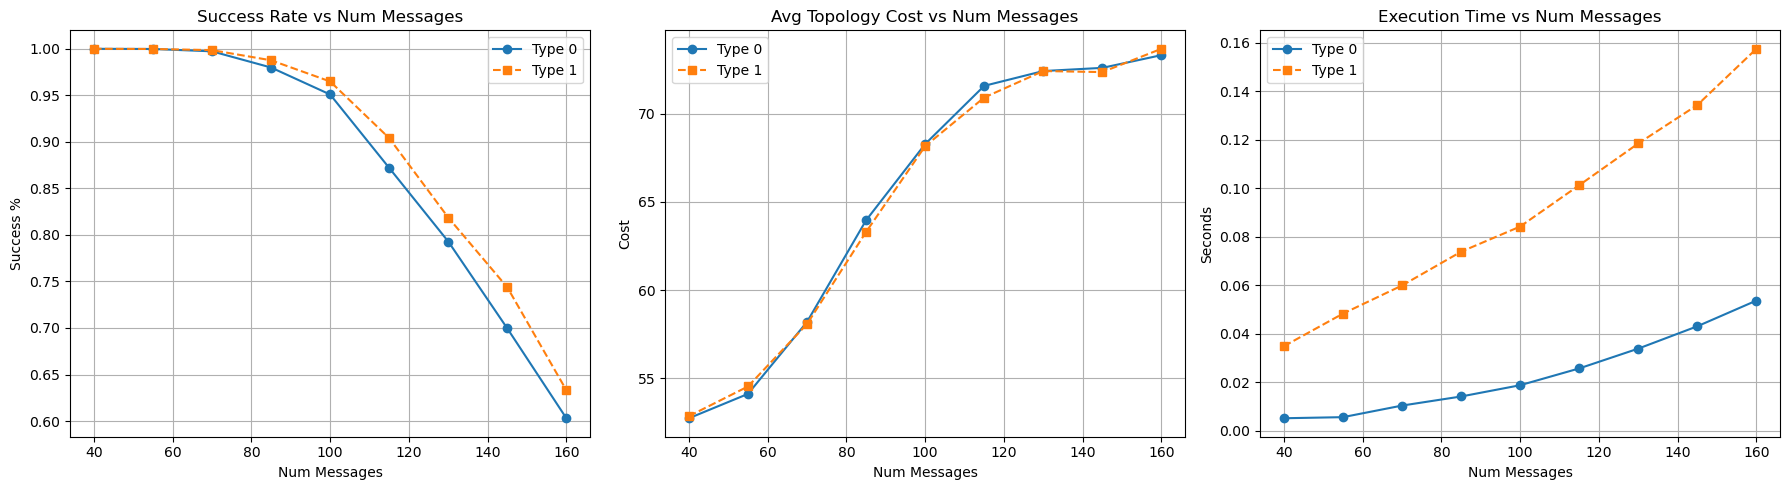

In [10]:
# --- Setup Parameters ---
num_ecu, num_bridges = 6, 6
bridge_limit, link_build_cost = 4, 2
base_period = int(1e2 // 12)
period_choice = tsn.VectorInt([1,2,3,10])
period_choice_weights = tsn.Vectordouble([0.1,0.1,0.1,0.7])
min_size, max_size = 1,1
min_tl, max_tl = 2, 2
yens_kmax = 20

# --- Run Experiments ---
x_axis, data_0 = run_experiment(0,message_counts = [40 + 15 * i for i in range(9)])
x_axis, data_1 = run_experiment(1,message_counts = [40 + 15 * i for i in range(9)])

# --- Plotting ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. Success Rate
axs[0].plot(x_axis, data_0["success_rate"], 'o-', label='Type 0')
axs[0].plot(x_axis, data_1["success_rate"], 's--', label='Type 1')
axs[0].set_title('Success Rate vs Num Messages')
axs[0].set_xlabel('Num Messages')
axs[0].set_ylabel('Success %')
axs[0].legend()
axs[0].grid(True)

# 2. Average Topology Cost
axs[1].plot(x_axis, data_0["avg_cost"], 'o-', label='Type 0')
axs[1].plot(x_axis, data_1["avg_cost"], 's--', label='Type 1')
axs[1].set_title('Avg Topology Cost vs Num Messages')
axs[1].set_xlabel('Num Messages')
axs[1].set_ylabel('Cost')
axs[1].legend()
axs[1].grid(True)

# 3. Execution Time
axs[2].plot(x_axis, data_0["avg_time"], 'o-', label='Type 0')
axs[2].plot(x_axis, data_1["avg_time"], 's--', label='Type 1')
axs[2].set_title('Execution Time vs Num Messages')
axs[2].set_xlabel('Num Messages')
axs[2].set_ylabel('Seconds')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()